In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('new dataset/online_retail_II.csv')
# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create useful columns
df['TotalRevenue'] = df['Quantity'] * df['Price']
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour
df['IsCancelled'] = df['Invoice'].astype(str).str.startswith('C').astype(int)

# Filter out cancelled orders and negative quantities
df_clean = df[(df['Quantity'] > 0) & (df['IsCancelled'] == 0)]

print("Dataset shape after cleaning:", df_clean.shape)
print("\nFirst few rows:")
print(df_clean.head())

Dataset shape after cleaning: (1044420, 13)

First few rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  TotalRevenue  \
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom          83.4   
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom          81.0   
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom          81.0   
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom         100.8   
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom          30.0   

   Month  DayOfWeek  Hour  IsCancelled  
0     12          1     7 

              Quantity     Price  TotalRevenue     Month  DayOfWeek      Hour
Quantity      1.000000 -0.001946      0.731164 -0.005664  -0.006477 -0.018344
Price        -0.001946  1.000000      0.434955 -0.000357  -0.003346  0.002394
TotalRevenue  0.731164  0.434955      1.000000 -0.000333  -0.006410 -0.015480
Month        -0.005664 -0.000357     -0.000333  1.000000   0.021065  0.032591
DayOfWeek    -0.006477 -0.003346     -0.006410  0.021065   1.000000 -0.015551
Hour         -0.018344  0.002394     -0.015480  0.032591  -0.015551  1.000000


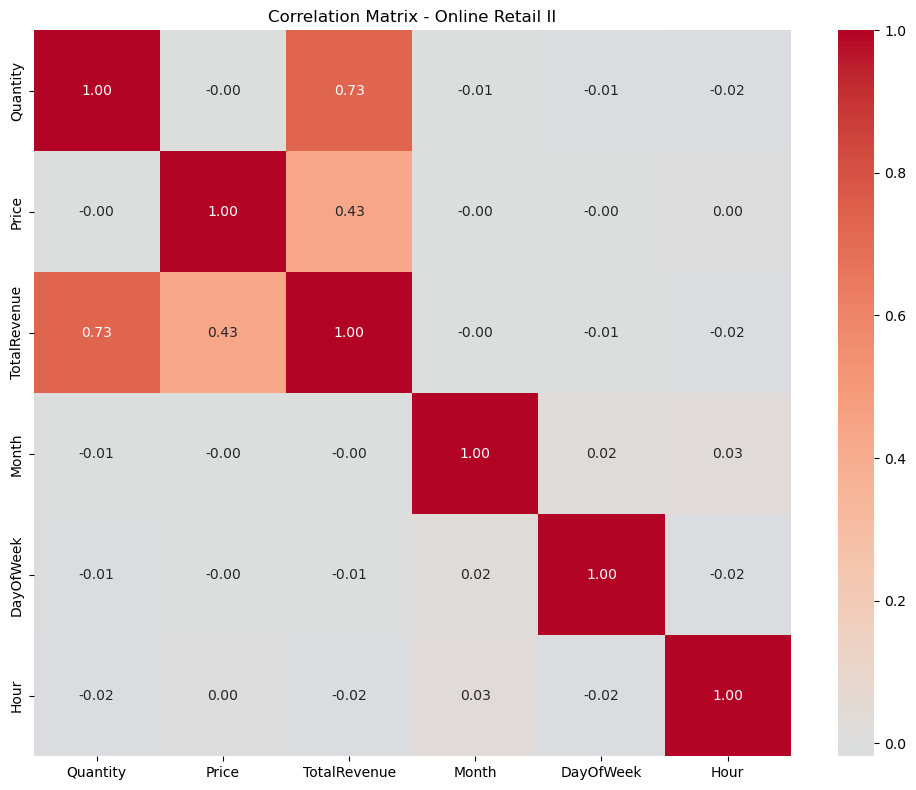

In [5]:
numeric_cols = ['Quantity', 'Price', 'TotalRevenue', 'Month', 'DayOfWeek', 'Hour']

corr_matrix = df_clean[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Online Retail II')
plt.tight_layout()
#plt.savefig('correlation_matrix.png')
plt.show()

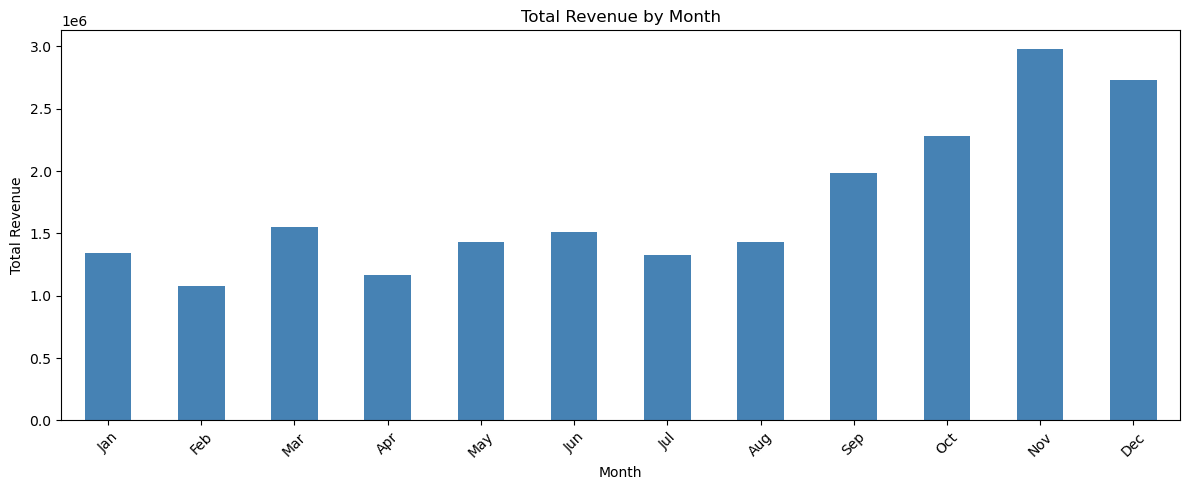

In [6]:
monthly_revenue = df_clean.groupby('Month')['TotalRevenue'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='bar', color='steelblue')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()

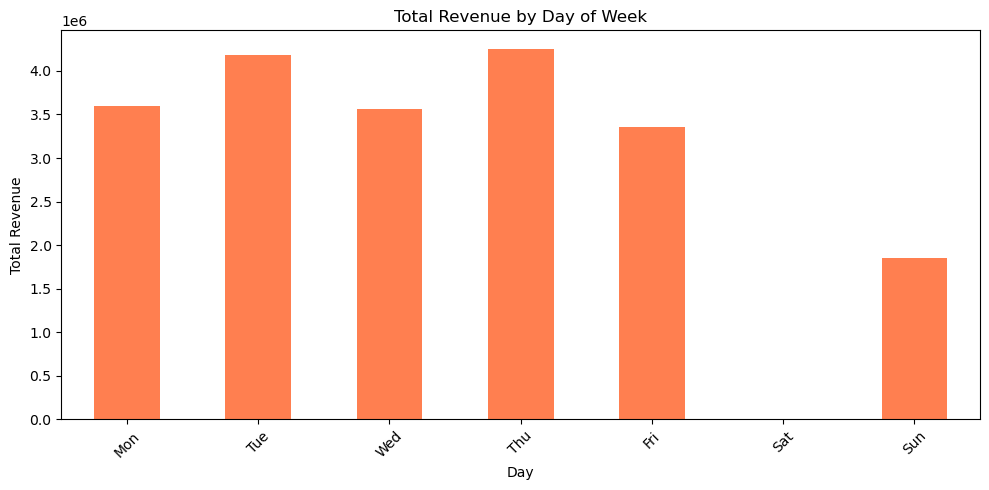

In [7]:
daily_revenue = df_clean.groupby('DayOfWeek')['TotalRevenue'].sum()

plt.figure(figsize=(10, 5))
daily_revenue.plot(kind='bar', color='coral')
plt.title('Total Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Revenue')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=45)
plt.tight_layout()
plt.savefig('daily_revenue.png')
plt.show()

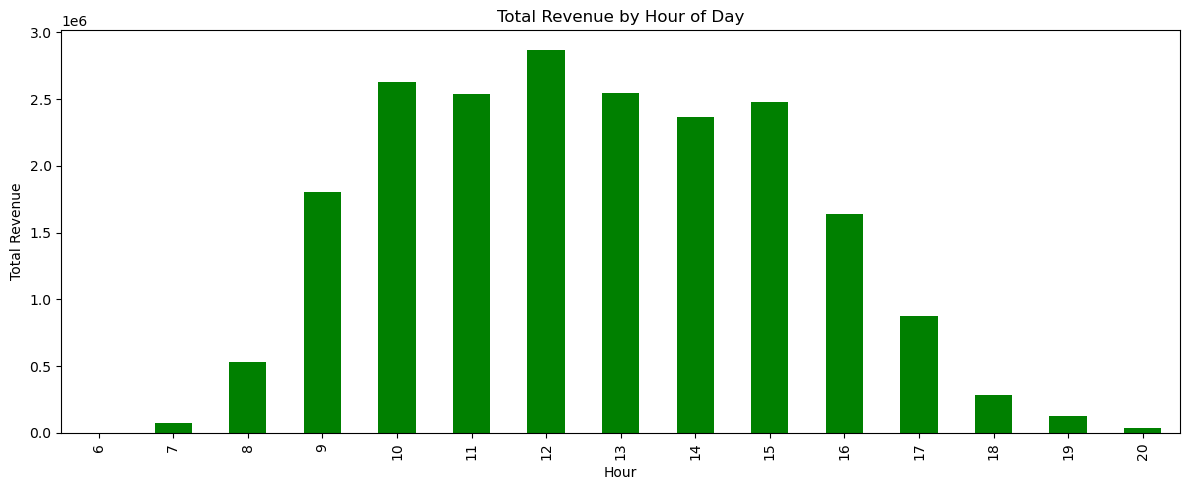

In [8]:
hourly_revenue = df_clean.groupby('Hour')['TotalRevenue'].sum()

plt.figure(figsize=(12, 5))
hourly_revenue.plot(kind='bar', color='green')
plt.title('Total Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.savefig('hourly_revenue.png')
plt.show()

In [9]:
print(df_clean['Country'].value_counts())

Country
United Kingdom          961223
EIRE                     17354
Germany                  16703
France                   13941
Netherlands               5093
Spain                     3720
Switzerland               3137
Belgium                   3069
Portugal                  2562
Australia                 1815
Channel Islands           1569
Italy                     1468
Norway                    1437
Sweden                    1338
Cyprus                    1155
Finland                   1032
Austria                    922
Denmark                    798
Unspecified                752
Greece                     657
Poland                     512
Japan                      485
United Arab Emirates       467
USA                        409
Israel                     369
Hong Kong                  358
Singapore                  339
Malta                      282
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        168


In [12]:
european_countries = [
    'United Kingdom', 'EIRE', 'Germany', 'France', 
    'Netherlands', 'Spain', 'Switzerland', 'Belgium', 
    'Portugal', 'Channel Islands', 'Italy', 'Norway', 
    'Sweden', 'Cyprus', 'Finland', 'Austria', 'Denmark', 
    'Greece','Poland', 'Czech Republic'
]

df_eu = df_clean[df_clean['Country'].isin(european_countries)]
print("European dataset size:", df_eu.shape)
print(f"Percentage of total data: {len(df_eu)/len(df_clean)*100:.1f}%")

print("\nCorrelation between Quantity and Revenue by Country:")
for country in european_countries:
    subset = df_eu[df_eu['Country'] == country]
    if len(subset) > 10:
        corr = subset['Quantity'].corr(subset['TotalRevenue'])
        print(f"{country}: {corr:.4f}")

European dataset size: (1037715, 13)
Percentage of total data: 99.4%

Correlation between Quantity and Revenue by Country:
United Kingdom: 0.7725
EIRE: 0.5105
Germany: 0.4233
France: 0.2822
Netherlands: 0.7534
Spain: 0.8106
Switzerland: 0.4203
Belgium: 0.0963
Portugal: 0.1748
Channel Islands: 0.7360
Italy: 0.3356
Norway: 0.0083
Sweden: 0.5404
Cyprus: 0.3929
Finland: 0.3355
Austria: 0.3342
Denmark: 0.7401
Greece: 0.3716
Poland: 0.3564
Czech Republic: -0.1725
